# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [8]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random
import warnings

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))
import torch
torch.set_float32_matmul_precision('high')

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.11.0+cu128
CUDA available: True


In [9]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc20'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
DATA_LIMIT = 55000
FIT_BATCH_SIZE = 256
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10

# First capacity trial: widen moderately, add one transformer block, and make
# direct/local structural supervision a little denser without going all the way
# to the full O(n^2) pair set.
EMBEDDING_DIM = 192
LEARNING_RATE = 1e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.35

# Capacity knobs. If this still underfits, the next escalation is d=256 with
# the same batch/LR before increasing depth again.
NUMBER_OF_TRANSFORMER_LAYERS = 4
TRANSFORMER_ATTENTION_HEAD_COUNT = 8
TRANSFORMER_DROPOUT = 0.15

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-s{DATA_LIMIT}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-l{NUMBER_OF_TRANSFORMER_LAYERS}-drop{TRANSFORMER_DROPOUT:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
# Keep preprocessing serial for the non-streaming notebook. The parallel
# vectorizer/feasibility path can wedge in long-lived notebook kernels before
# training starts, leaving no useful progress output.
VECTORIZER_PARALLEL = False
FEASIBILITY_PARALLEL = False
FEASIBILITY_N_JOBS = 1
DECODER_N_JOBS = 1
DECODER_SOLVER_THREADS = 16

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [10]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    node_vectorizer_parallel=VECTORIZER_PARALLEL,
    graph_vectorizer_parallel=VECTORIZER_PARALLEL,
    feasibility_parallel=FEASIBILITY_PARALLEL,
    feasibility_n_jobs=FEASIBILITY_N_JOBS,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    decoder_solver_threads=DECODER_SOLVER_THREADS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}
TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


ZINC CSV: /cs0eth/home/fc334/code/NodeField/notebooks/datasets/zinc/zinc20.csv
Loaded 55000 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc20-nonstreaming-d192-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/zinc20-nonstreaming-d192-s55000-b256-lr0.0001-mask0.35-l4-drop0.15-e350/training_samples.pdf


In [ ]:
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=50,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


Fit target model_name=zinc20-nonstreaming-d192-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 55000 graphs
Fitting graph vectorizer on 55000 graphs
Finished fitting graph vectorizer on 55000 graphs in 0m 0.0s
Fitting node graph vectorizer on 55000 graphs
Finished fitting node graph vectorizer on 55000 graphs in 0m 0.0s
Encoding node embeddings for 55000 graphs
Finished encoding node embeddings for 55000 graphs in 56m 22.2s
Encoding graph embeddings for 55000 graphs
Finished encoding graph embeddings for 55000 graphs in 52m 50.1s
Fitting embedding SVDs


In [ ]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc15-nonstreaming-d64-s10000-b128-e350'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.solver_threads = DECODER_SOLVER_THREADS


,name,modified,size_mb
0,zinc20-nonstreaming-d192-s33000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 23:16,70.500000
1,zinc20-nonstreaming-d192-s5000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 14:53,29.000000
2,zinc20-nonstreaming-d192-s1000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 11:22,23.100000
3,artificial-cycle-path-star-n60000-c4-nc2-p2-r2x2-d128-b128-e350.pkl,2026-06-08 13:50,70.900000
4,zinc20-nonstreaming-d128-s50000-b512-lr0-0002-mask0-5-e350.pkl,2026-06-05 20:06,61.000000
5,artificial-cycle-path-star-n6000-c4-nc2-p2-r2x2-d64-b128-e350.pkl,2026-06-05 20:01,8.900000
6,artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:40,8.900000
7,artificial-cycle-path-star-n2500-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:18,7.100000
8,artificial-cycle-path-star-n2500-c3-p2-r2x1-d64-b128-e350.pkl,2026-06-05 17:01,7.100000
9,zinc18-nonstreaming-d128-s30000-b512-lr0-0002-mask0-5-e350.pkl,2026-06-05 16:52,41.200000


Loaded graph generator: zinc20-nonstreaming-d192-s33000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl
/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/zinc20-nonstreaming-d192-s33000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl


Non-streaming ZINC raw samples


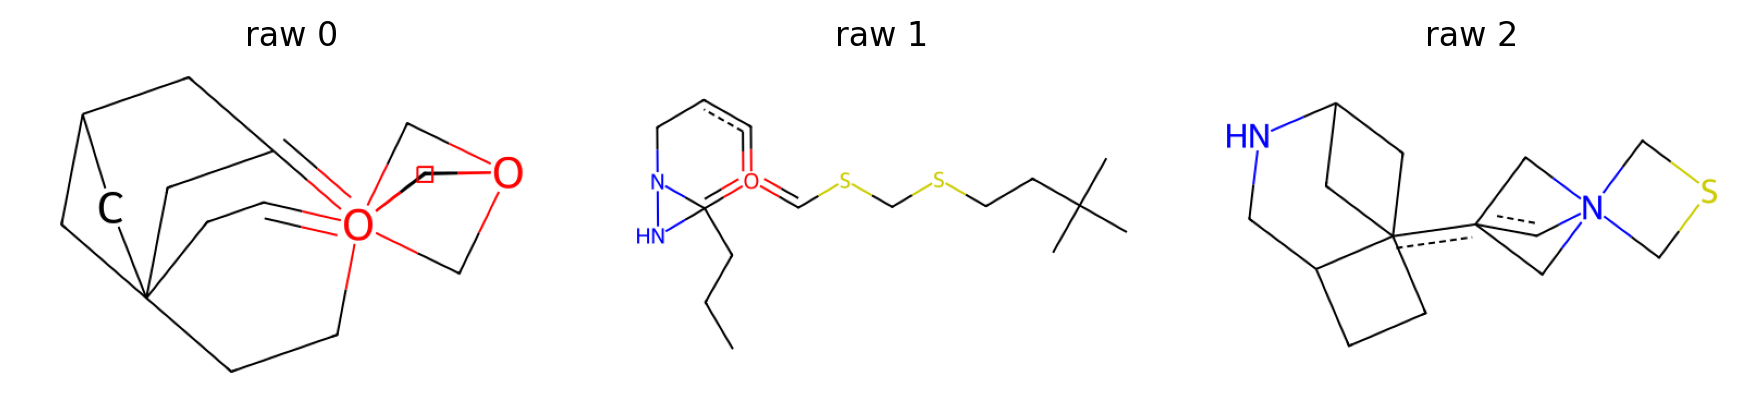

Non-streaming ZINC ilp samples


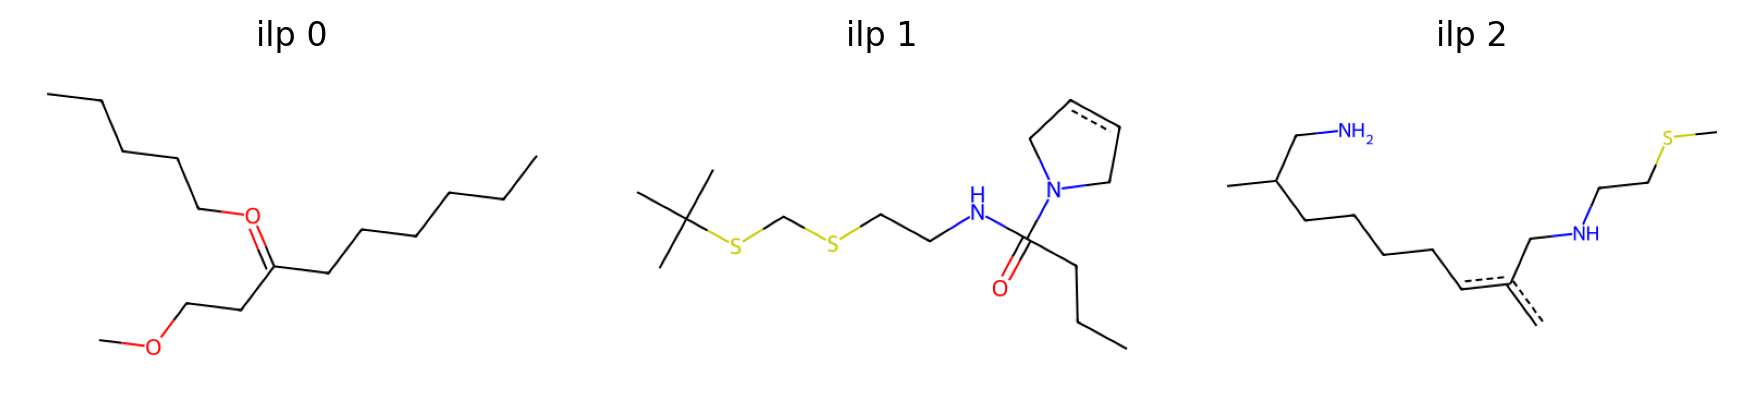

Non-streaming ZINC oracle ilp samples


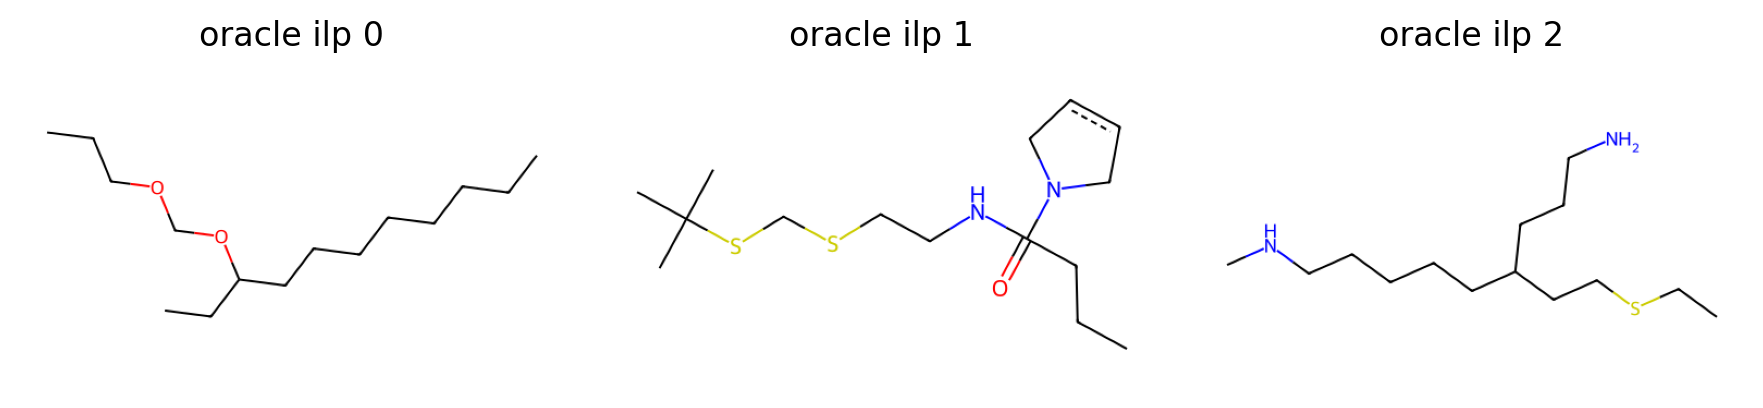

In [ ]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = [graph for graph in sample_variants[variant_key] if graph is not None]
    if not variant_samples:
        print(f'No {title_prefix} samples to display.')
        continue
    show_molecules(
        variant_samples,
        n=len(variant_samples),
        title=f'Non-streaming ZINC {title_prefix} samples',
        legends=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
        n_graphs_per_line=n_samples,
    )


Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 3 | feasible_rate= 37.5% | attempt_time=   25.1s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=3, feasible_rate=37.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 8 | feasible_rate=100.0% | attempt_time=   18.3s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=8, feasible_rate=100.0%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 2 | feasible_rate= 25.0% | attempt_time=18m 10.5s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=2, feasible_rate=25.0%, fulfilled_slots=1/1.
Generation summary: requested=3, returned=3, generated=24, candidate_feasible=13 (54.2%), feasible=3 (100.0%), unfiltered=0 (0.0%), rejected=0 (0.0%).
Non-streaming ZINC samples with feasibility filtering


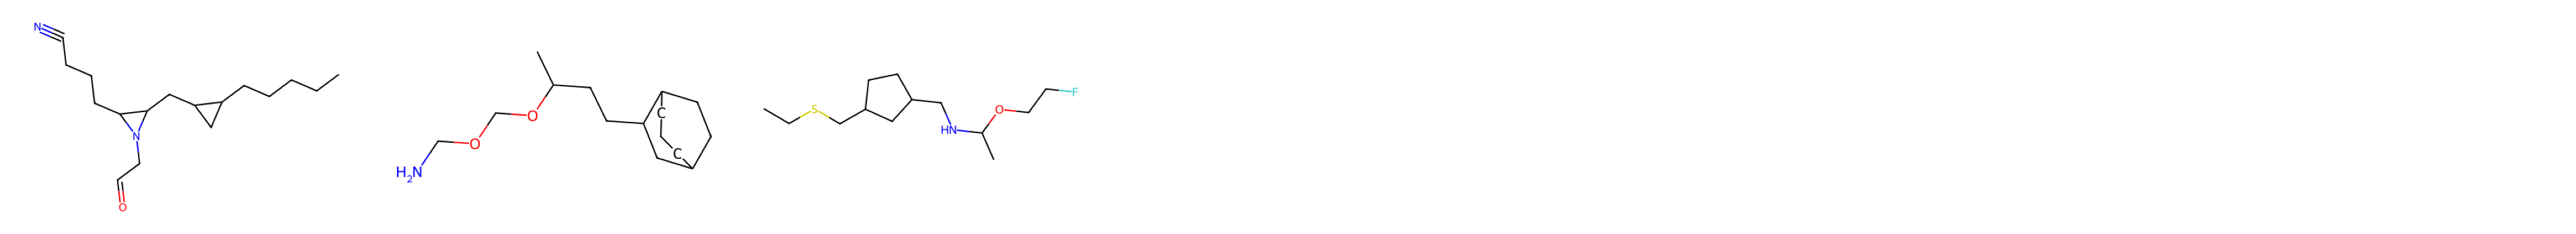

In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=n_samples, title='Non-streaming ZINC samples with feasibility filtering')
